# Experiment I

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
from tensorflow.keras.utils import set_random_seed

set_random_seed(0)

# input
input = Input(shape =(32,32,3))

# 1st Conv Block
x = Conv2D (filters =4, kernel_size =5, padding ='same', activation='relu')(input)
x = Conv2D (filters =8, kernel_size =5, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

x = Conv2D (filters =16, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =16, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

x = Conv2D (filters =32, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =64, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

#Fully Connected Layer
x = Flatten()(x)
x = Dense(units = 16, activation ='relu')(x)
x = Dense(units = 32, activation ='relu')(x)
output = Dense(units = 10, activation ='softmax')(x)

# creating the model
model = Model (inputs=input, outputs =output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 4)         304       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 8)         808       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 8)        0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 16)        1168      
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 16)        2320      
                                                             

In [1]:
!pip install pydot
!pip install pydotplus
!pip install graphviz

In [4]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file="model.png", show_shapes=True, show_layer_names = False, dpi=1000, show_layer_activations=True, expand_nested=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model/model_to_dot to work.


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 8s 0us/step


In [6]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [7]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=5,
)

Fit model on training data
Epoch 1/5
782/782 [==============================] - 99s 123ms/step - loss: 2.0129 - sparse_categorical_accuracy: 0.2209
Epoch 2/5
782/782 [==============================] - 98s 126ms/step - loss: 1.6150 - sparse_categorical_accuracy: 0.3968
Epoch 3/5
782/782 [==============================] - 83s 106ms/step - loss: 1.3987 - sparse_categorical_accuracy: 0.4943
Epoch 4/5
782/782 [==============================] - 89s 114ms/step - loss: 1.2814 - sparse_categorical_accuracy: 0.5444
Epoch 5/5
782/782 [==============================] - 91s 117ms/step - loss: 1.1923 - sparse_categorical_accuracy: 0.5793


In [8]:
print("Evaluate on test data")
results = model.evaluate(x_test, y_test)

Evaluate on test data
313/313 [==============================] - 6s 18ms/step - loss: 1.2476 - sparse_categorical_accuracy: 0.5519


In [15]:
model.save("experiments/exp1/model/")

INFO:tensorflow:Assets written to: experiments/exp1/model/assets


INFO:tensorflow:Assets written to: experiments/exp1/model/assets


In [10]:
print(y_test)

[[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]


In [9]:
import numpy
predictions = model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)
print(predictions)

313/313 [==============================] - 6s 18ms/step
[[7.20415963e-04 2.02590437e-03 4.51138988e-02 ... 2.01302934e-02
  1.57847803e-03 2.88731996e-02]
 [5.16071953e-02 1.31065488e-01 4.67862905e-04 ... 4.32398394e-07
  8.11800182e-01 4.87254979e-03]
 [7.80221224e-02 2.51974940e-01 4.22400143e-03 ... 1.41768553e-03
  4.34876740e-01 2.21469089e-01]
 ...
 [2.60447641e-03 2.91734381e-04 1.88608795e-01 ... 2.58446336e-02
  5.73948957e-04 1.60642411e-03]
 [8.88906792e-02 7.72982001e-01 2.16037277e-02 ... 1.30113335e-02
  2.25359406e-02 6.17285632e-02]
 [9.93965004e-05 1.99956248e-05 2.02435930e-03 ... 9.27621365e-01
  8.33736806e-07 8.04382580e-05]]


In [11]:
import numpy
predictions = model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")

313/313 [==============================] - 6s 20ms/step
matched numbers : 5519
non matched numbers : 4481


In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ImportError: cannot import name 'ConfusionMatrixDisplay' from 'sklearn.metrics' (C:\Users\Usman Electronics\Anaconda3\lib\site-packages\sklearn\metrics\__init__.py)

In [19]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.0.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: None
Author-email: None
License: new BSD
Location: c:\users\usman electronics\anaconda3\lib\site-packages
Requires: joblib, scipy, threadpoolctl, numpy
Required-by: 


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = predicted_number
y_test = y_test
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.svg", dpi=1000)
plt.show()

ImportError: cannot import name 'ConfusionMatrixDisplay' from 'sklearn.metrics' (C:\Users\Usman Electronics\Anaconda3\lib\site-packages\sklearn\metrics\__init__.py)

In [14]:
!pip install scikit-learn


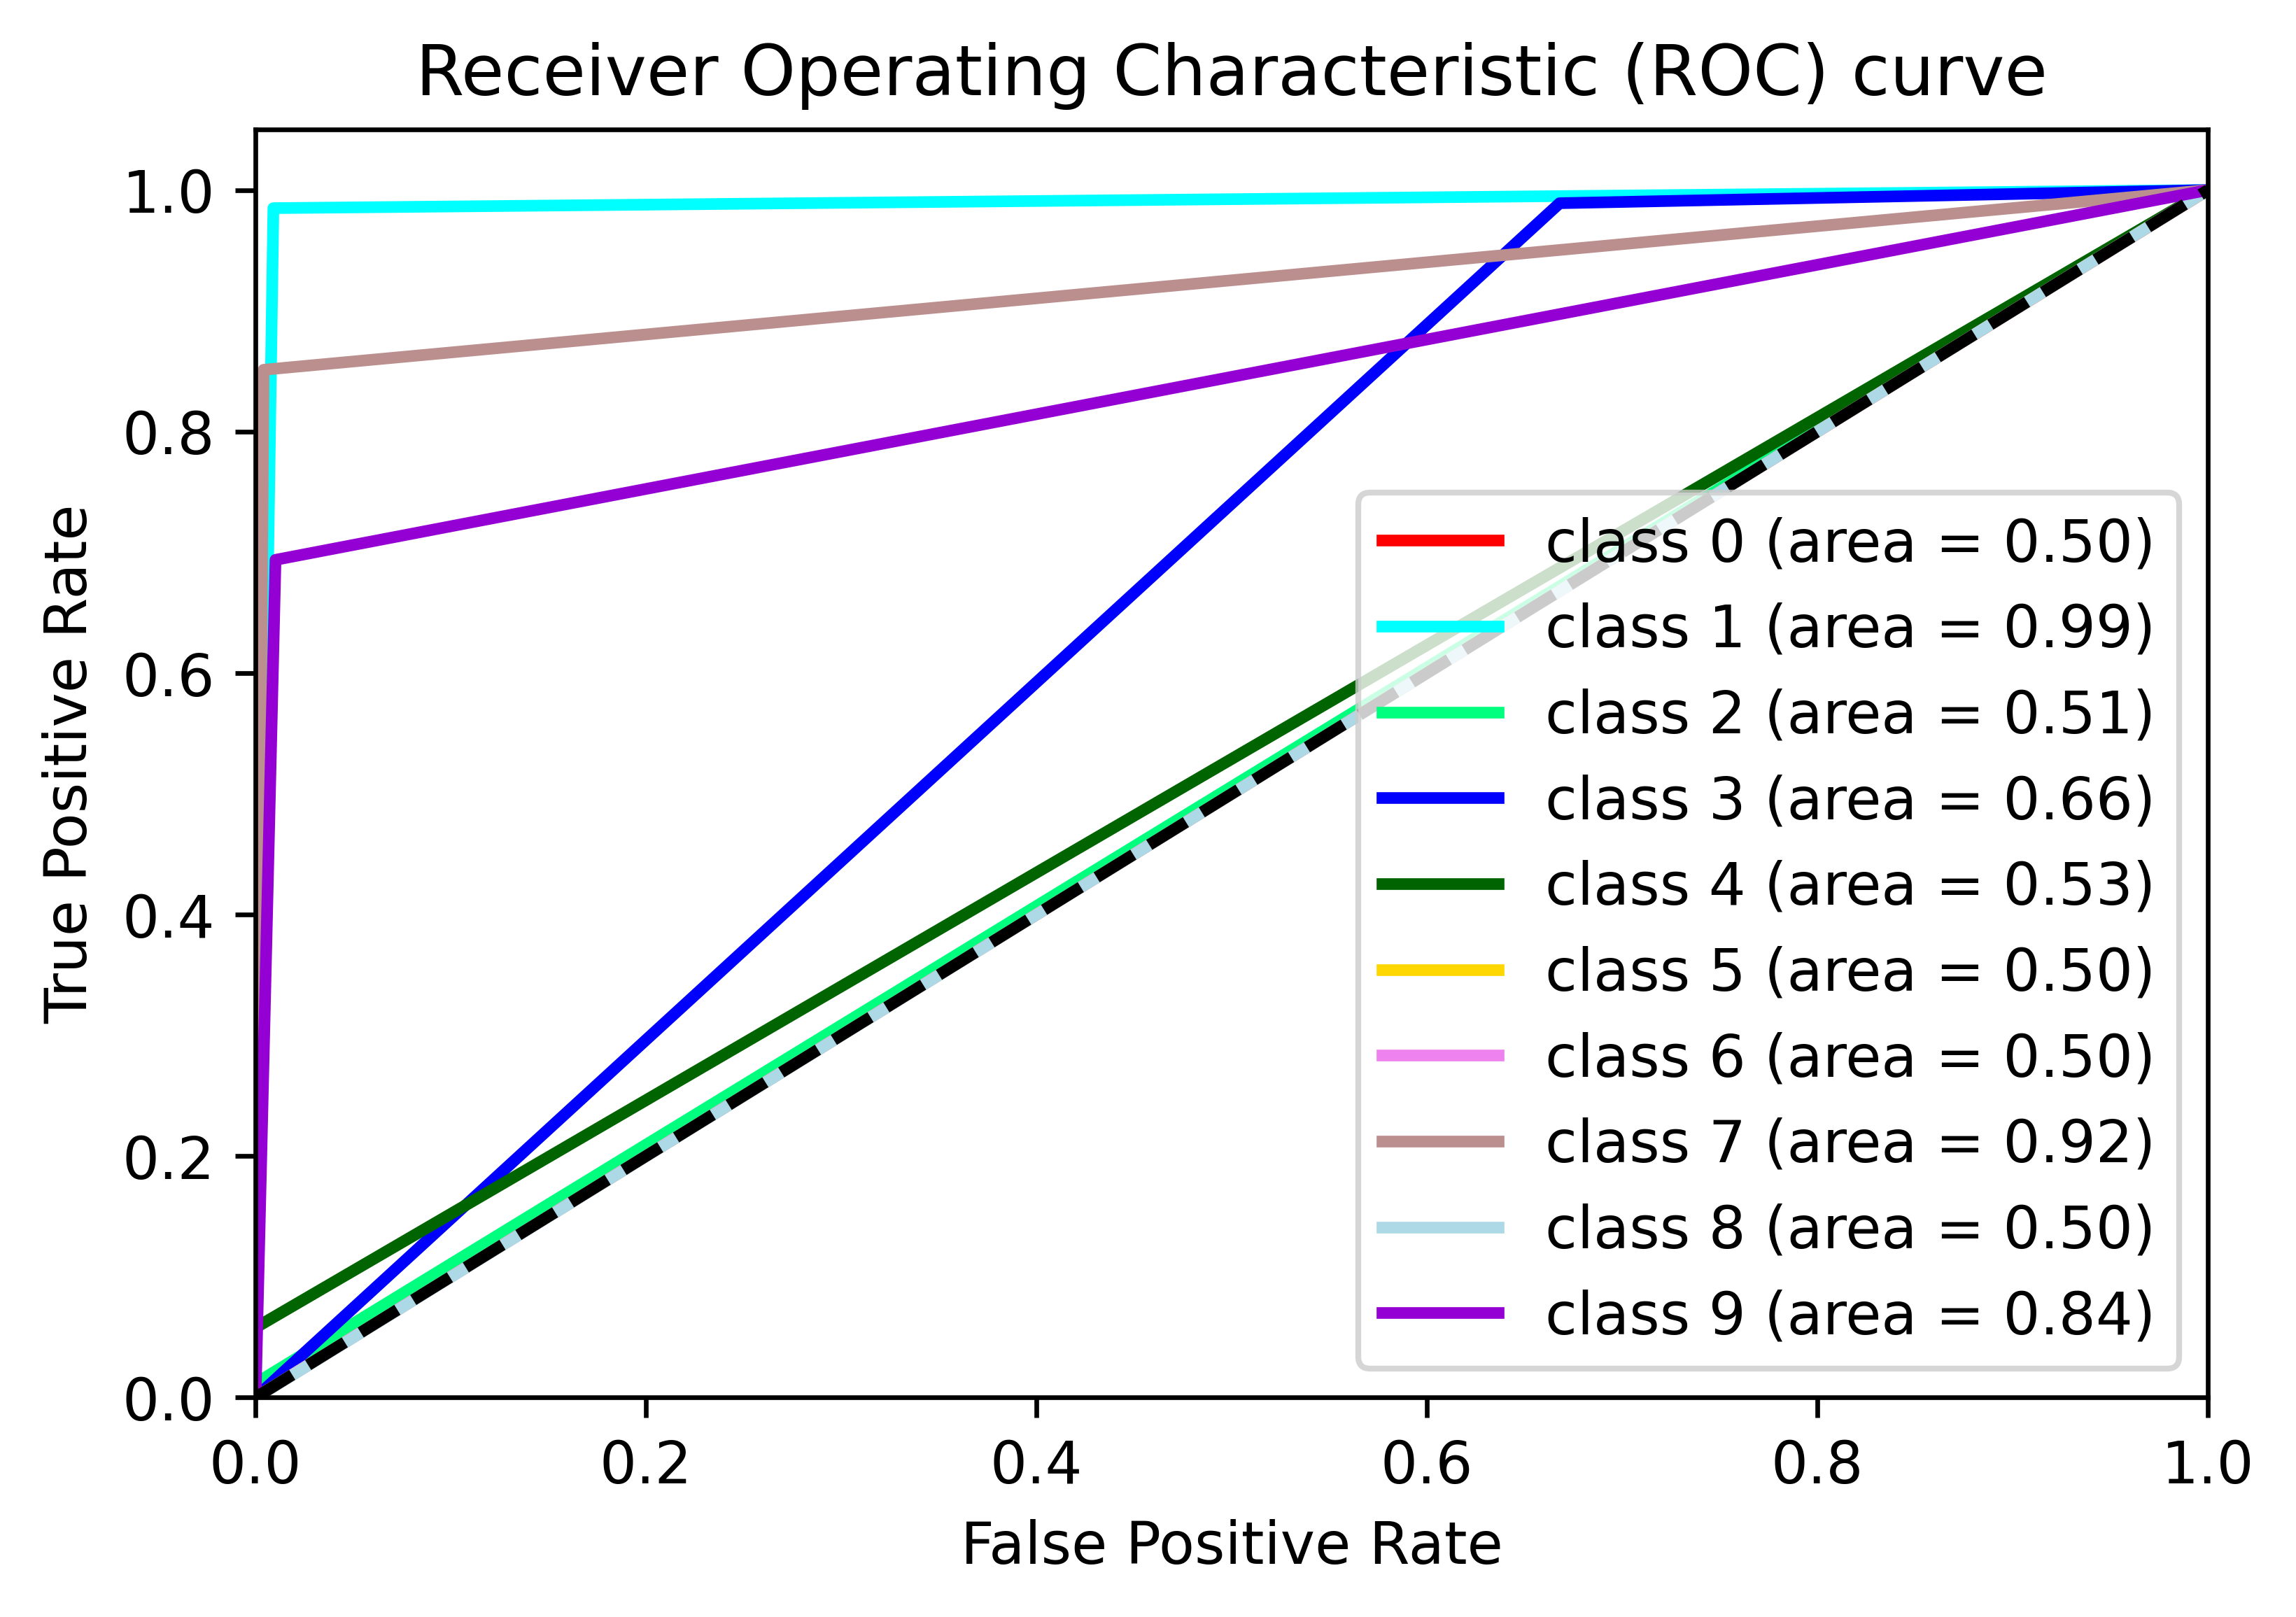

In [9]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = len(np.unique(y_test))
y_labelized_test = label_binarize(y_test, classes=np.arange(n_classes))
y_labelized_pred = label_binarize(predicted_number, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()
for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_labelized_test[:, i], y_labelized_pred[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_labelized_test.ravel(), y_labelized_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])


# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2




colors = cycle(["red", "cyan", "springgreen", "blue", "darkgreen", "gold", "violet", "rosybrown", "lightblue", "darkviolet"])
for i, color in zip(range(n_classes), colors):
    #print(i, roc_auc)
    string_label = f"class {i} (area = {roc_auc[i]:0.2f})"
    plt.plot(fpr[i], tpr[i], color=color, 
             lw=lw,label=string_label,)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.legend()
plt.savefig("experiments/exp1/ROC.jpg", bbox_inches="tight", dpi=1000)

In [10]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [11]:
f1_score(y_test, y_pred, average=None)

array([0.        , 0.958012  , 0.02634055, 0.2493137 , 0.10951009,
       0.        , 0.        , 0.90206186, 0.        , 0.77734592])

In [12]:
precision_score(y_test, y_pred, average=None)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


array([0.        , 0.9324437 , 0.4516129 , 0.14263278, 0.96610169,
       0.        , 0.        , 0.95942982, 0.        , 0.88383838])

In [13]:
recall_score(y_test, y_pred, average=None)

array([0.        , 0.98502203, 0.01356589, 0.98910891, 0.05804481,
       0.        , 0.        , 0.85116732, 0.        , 0.69375619])

In [14]:
accuracy_score(y_test, y_pred)

0.3763